# MRS Bulletin Figures
> Georgios Varnavides, Willem de Kleijne, Stephanie Ribet

## CTFs Figure

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr
from matplotlib import colormaps

In [2]:
# parameters
n = 192
q_max = 2 # inverse Angstroms
q_probe = 1 # inverse Angstroms
wavelength = 0.019687 # 300kV
sampling = 1 / q_max / 2 # Angstroms
reciprocal_sampling = 2 * q_max / n # inverse Angstroms

scan_step_size = 1 # pixels
sx = sy = n//scan_step_size
phi0 = 1.0

aberrations = [
    {},
    {"C10":1e2},
    {"C10":1e2,"C30":1e6}
]

In [3]:
def return_chi(
    alpha,
    theta,
    wavelength,
    C10=0,
    C30=0,
    C12=0,
    phi12=0,
    C21=0,
    phi21=0,
):
    """ """
    prefactor = 2*np.pi / wavelength
    order_2 = alpha**2 / 2 * (C10 + C12 * np.cos(2 * (theta - phi12))) 
    order_3 = alpha**3 / 3 * C21 * np.cos(theta-phi21)
    order_4 = alpha**4 / 4 * C30
    
    return (order_2 + order_3 + order_4) * prefactor

qx = qy = np.fft.fftfreq(n,sampling)
q2 = qx[:,None]**2 + qy[None,:]**2
q  = np.sqrt(q2)

theta = np.arctan2(qy[None,:],qx[:,None])
alpha = q * wavelength

aperture_fourier = np.clip(
    (q_probe - q)/reciprocal_sampling + 0.5,
    0,
    1,
)


chis = []
probe_fourier_arrays = []

for aberration in aberrations:
    chi = return_chi(alpha,theta,wavelength,**aberration)
    chis.append(chi)
    probe_fourier_arrays.append(aperture_fourier * np.exp(-1j*chi))

BF_weight = np.sum(aperture_fourier**2)

bf_mask = aperture_fourier > 0
bf_inds_i, bf_inds_j = np.where(bf_mask)

In [4]:
qxa, qya = np.meshgrid(qx,qy,indexing='ij')
kxa, kya = qxa.copy(), qya.copy()

kx = kxa[bf_inds_i,bf_inds_j][:,None,None]
ky = kya[bf_inds_i,bf_inds_j][:,None,None]

qmkxa = qxa[None,:,:] - kx
qmkya = qya[None,:,:] - ky
qpkxa = qxa[None,:,:] + kx
qpkya = qya[None,:,:] + ky

q_m = np.sqrt(qmkxa**2 + qmkya**2)
phi_m = np.arctan2(qmkya,qmkxa)

gammas = []

for aberration, probe_array_fourier in zip(aberrations,probe_fourier_arrays):
    exp_chi_m = np.exp(-1j*return_chi(q_m * wavelength,phi_m,wavelength,**aberration))
    aperture_m = np.clip((q_probe - q_m)/reciprocal_sampling + 0.5,0,1)
    probe_m = aperture_m * exp_chi_m
    # probe_m /= np.sqrt(np.sum(np.abs(probe_m)**2))
    
    q_p = np.sqrt(qpkxa**2 + qpkya**2)
    phi_p = np.arctan2(qpkya,qpkxa)
    
    exp_chi_p = np.exp(-1j*return_chi(q_p * wavelength,phi_p,wavelength,**aberration))
    aperture_p = np.clip((q_probe - q_p)/reciprocal_sampling + 0.5,0,1)
    probe_p = aperture_p * exp_chi_p
    # probe_p /= np.sqrt(np.sum(np.abs(probe_p)**2))
    
    fourier_probe_k = probe_array_fourier[bf_inds_i, bf_inds_j][:,None,None]
    gamma = probe_m * fourier_probe_k.conj() - probe_p.conj() * fourier_probe_k
    gammas.append(gamma)

In [5]:
def autocorrelation(array):
    """ """
    return np.real(
        np.fft.ifft2(
            np.abs(
                np.fft.fft2(
                    array
                )
            )**2
        )
    )

analytical_ctfs = np.empty((3,5,n,n))
analytical_ssnrs = np.empty((3,5,n,n))

epsilon = 1e-2
aperture_autocorrelation = autocorrelation(aperture_fourier / np.sqrt(BF_weight))
for i, (gamma, chi, probe_array_fourier) in enumerate(zip(gammas,chis,probe_fourier_arrays)):
    
    abs_gamma = np.abs(gamma)
    gamma_energy = np.sum(abs_gamma**2,0) / BF_weight
    
    ssb_noise = np.sqrt(np.sum(abs_gamma>0,axis=0) / BF_weight)
    ssb_noise[ssb_noise<=0] = np.inf
    
    analytical_ctfs[i,0] = abs_gamma.sum(0) / BF_weight / 2
    analytical_ctfs[i,1] = np.sqrt(gamma_energy) / 2
    analytical_ctfs[i,2] = gamma_energy / (gamma_energy + epsilon*gamma_energy.max())
    analytical_ctfs[i,3] = - np.sin(chi) * aperture_autocorrelation
    analytical_ctfs[i,4] = autocorrelation(probe_array_fourier / np.sqrt(BF_weight))

    analytical_ssnrs[i,0] = np.abs(analytical_ctfs[i,0]) / ssb_noise
    analytical_ssnrs[i,1] = np.abs(analytical_ctfs[i,1])
    analytical_ssnrs[i,2]  = analytical_ssnrs[i,1].copy()
    analytical_ssnrs[i,3]  = np.abs(analytical_ctfs[i,3].copy())
    analytical_ssnrs[i,4] = q * np.abs(analytical_ctfs[i,4])

analytical_combined = np.fft.fftshift(
    np.concatenate((analytical_ssnrs[...,:n//2],analytical_ctfs[...,n//2:]),axis=3),
    axes=(-1,-2)
).reshape((-1,n,n))



In [6]:
def radially_average_ctf(corner_centered_ctf,sampling):
    """ returns the radially-averaged CTF of a corner-centered 2D CTF array. """
    nx, ny = corner_centered_ctf.shape
    sx, sy = sampling
    
    kx = np.fft.fftfreq(nx,sx)
    ky = np.fft.fftfreq(ny,sy)
    k  = np.sqrt(kx[:,None]**2 + ky[None,:]**2).ravel()

    intensity = corner_centered_ctf.ravel()

    bin_size = kx[1]-kx[0]
    k_bins = np.arange(0, k.max() + bin_size, bin_size)

    inds = k / bin_size
    inds_f = np.floor(inds).astype("int")
    d_ind = inds - inds_f

    nf = np.bincount(inds_f, weights=(1 - d_ind), minlength=k_bins.shape[0])
    nc = np.bincount(inds_f + 1, weights=(d_ind), minlength=k_bins.shape[0])
    n = nf + nc

    I_bins0 = np.bincount(
        inds_f, weights=intensity * (1 - d_ind), minlength=k_bins.shape[0]
    )
    I_bins1 = np.bincount(
        inds_f + 1, weights=intensity * (d_ind), minlength=k_bins.shape[0]
    )

    I_bins = (I_bins0 + I_bins1) / n

    inds = k_bins <= np.abs(kx).max()

    return k_bins[inds], I_bins[inds]

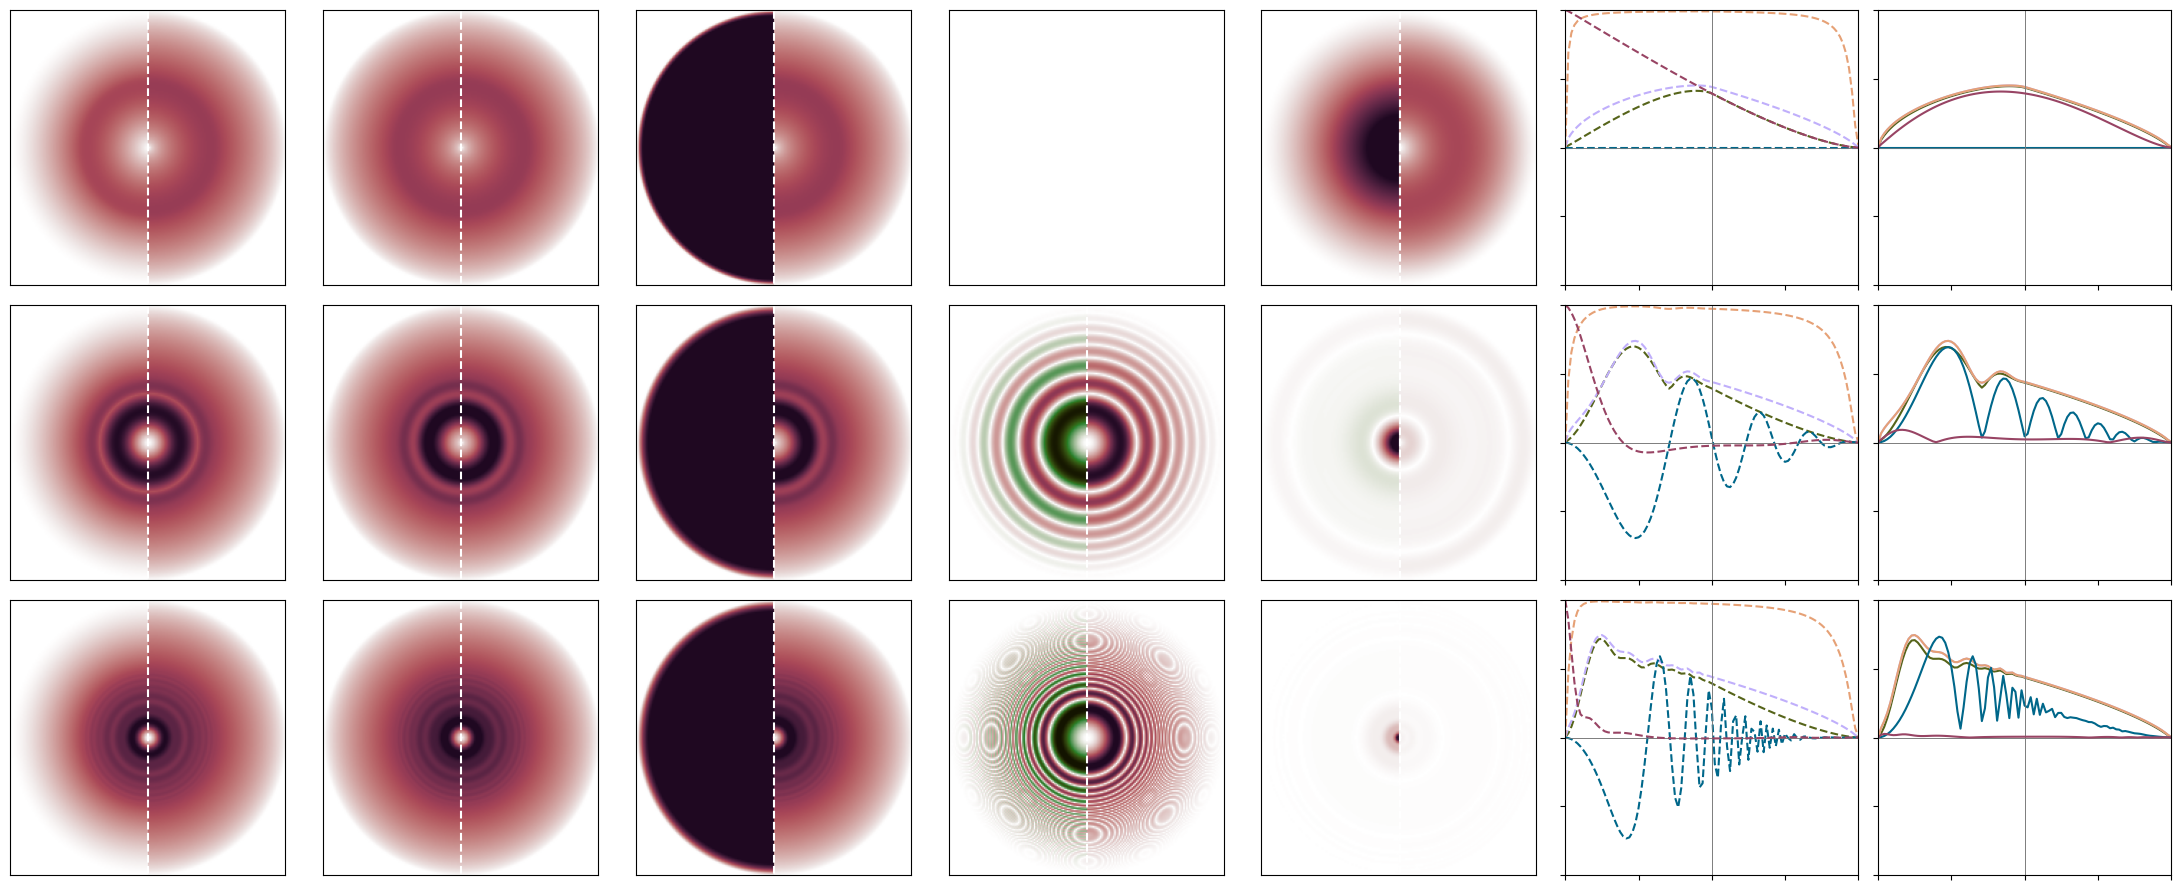

In [8]:
cmap = cmr.holly
# cols = colormaps.get_cmap("Paired")(np.arange(1,10,2))
cols = ["#56641a","#c0affb","#e6a176","#00678a","#984464"]
vmax = np.sqrt(2)/2

fig, axs = plt.subplots(3,7,figsize=(7*3 + 1,3*3))

for ax, arr in zip(axs[:,:5].flat,analytical_combined):
    ax.imshow(arr,vmin=-vmax,vmax=vmax,cmap=cmap)
    ax.vlines(n//2,0,n-1,color='white',linestyle='--')
    ax.set(xticks=[],yticks=[])
    
for ax, ctfs in zip(axs[:,5],analytical_ctfs):
    for ctf, col in zip(ctfs,cols):
        q_bins, I_bins = radially_average_ctf(ctf,(sampling,sampling))
        ax.vlines(1,-1,1,color='gray',linestyles='-',linewidth=0.5)
        ax.hlines(0,0,2,color='gray',linestyles='-',linewidth=0.5)
        ax.plot(q_bins,I_bins,color=col,linestyle='--')
        ax.sharex=axs[0,5]
        ax.set(xlim=[0,2],ylim=[-1,1],yticks=[-1,-0.5,0,0.5,1],xticklabels=[],yticklabels=[])

for ax, ssnrs in zip(axs[:,6],analytical_ssnrs):
    for ssnr, col in zip(ssnrs,cols):
        q_bins, I_bins = radially_average_ctf(ssnr,(sampling,sampling))
        ax.vlines(1,-1,1,color='gray',linestyles='-',linewidth=0.5)
        ax.hlines(0,0,2,color='gray',linestyles='-',linewidth=0.5)
        ax.plot(q_bins,I_bins,color=col)
        ax.sharex(axs[0,6])
        ax.sharey(axs[0,5])
        ax.set(xlim=[0,2],ylim=[-1,1],xticklabels=[],yticklabels=[])

for ax in axs.flat:
    ax.patch.set_alpha(0)
    
fig.patch.set_alpha(0)
fig.tight_layout()
fig.savefig("direct_ctfs_figure.pdf",bbox_inches='tight')
fig.savefig("direct_ctfs_figure.png",bbox_inches='tight')